In [22]:
import warnings
warnings.simplefilter('ignore')

%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import plotly
import plotly.graph_objs as go

from sklearn.metrics import mean_squared_error as mse
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
from datetime import datetime, timedelta

In [24]:
import haversine as hs
from haversine import Unit
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error as mse

df = pd.read_csv('C:/Users/fusb1/Desktop/Для диплома/Хлорофилл в Байкале по годам_необработанный/Baikal_1995.csv')
df.date = pd.to_datetime(df.date)
df.head(20)

,date,lat,lon,chla_mean,chla_uncertainty,lake_surface_water_temperature,lswt_quality_level,lswt_uncertainty,turbidity_mean,turbidity_uncertainty
0,1995-06-01,51.462500,104.504167,NaN,NaN,278.19998,1.0,0.167,NaN,NaN
1,1995-06-01,51.462500,104.512500,NaN,NaN,278.19998,1.0,0.167,NaN,NaN
2,1995-06-01,51.462500,104.745833,NaN,NaN,277.72998,1.0,0.166,NaN,NaN
3,1995-06-01,51.462500,104.770833,NaN,NaN,277.10000,4.0,0.166,NaN,NaN
4,1995-06-01,51.462500,104.779167,NaN,NaN,277.10000,4.0,0.166,NaN,NaN
5,1995-06-01,51.470833,104.487500,NaN,NaN,277.87000,3.0,0.167,NaN,NaN
6,1995-06-01,51.470833,104.495833,NaN,NaN,277.87000,3.0,0.167,NaN,NaN
7,1995-06-01,51.470833,104.504167,NaN,NaN,277.34000,4.0,0.167,NaN,NaN
8,1995-06-01,51.470833,104.512500,NaN,NaN,277.34000,4.0,0.167,NaN,NaN
9,1995-06-01,51.470833,104.520833,NaN,NaN,277.75000,3.0,0.167,NaN,NaN


In [54]:
import pandas as pd
import os

# Пути к файлам и папкам
input_file = 'C:/Users/fusb1/Desktop/Для диплома/Хлорофилл в Байкале по годам_необработанный/Baikal_2020.csv'
output_folder = 'C:/Users/fusb1/Desktop/Для диплома/Хлорофилл в Байкале по годам_обработанный'
output_filename = 'Весь_Байкал_только_Хлорофилл_2020.csv'

# Объединяем путь к новому файлу
output_path = os.path.join(output_folder, output_filename)

# Читаем CSV
df = pd.read_csv(input_file)

# Удаляем строки, где значение chla_mean отсутствует (NaN)
df_cleaned = df.dropna(subset=['chla_mean'])

# Оставляем только нужные столбцы
columns_to_keep = ['date', 'lat', 'lon', 'chla_mean', 'chla_uncertainty']
df_filtered = df_cleaned[columns_to_keep]

# Проверка на пустоту
if df_filtered.empty:
    name, ext = os.path.splitext(output_filename)
    output_filename = f"{name} (Empty){ext}"

# Полный путь к выходному файлу
output_path = os.path.join(output_folder, output_filename)

# Сохраняем файл
df_filtered.to_csv(output_path, index=False)

# Выводим результат
print(f'\nФайл сохранён: {output_path}')
if not df_filtered.empty:
    print('\nПервые 5 строк нового файла:')
    print(df_filtered.head())
else:
    print('\n Внимание: итоговый файл пуст — ни одной строки с chla_mean не найдено.')


Файл сохранён: C:/Users/fusb1/Desktop/Для диплома/Хлорофилл в Байкале по годам_обработанный\Весь_Байкал_только_Хлорофилл_2020.csv

Первые 5 строк нового файла:
          date        lat         lon  chla_mean  chla_uncertainty
80  2020-01-01  51.704167  105.729167   0.139177         64.649284
81  2020-01-01  51.704167  105.737500   0.137487         64.651460
82  2020-01-01  51.720833  105.754167  12.409741         59.364890
83  2020-01-01  51.729167  105.745833   2.035684         58.834290
84  2020-01-01  51.729167  105.754167   0.397340         61.019080


c:\Users\fusb1\AppData\Local\Programs\Python\Python313\Lib\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 27 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_11800\903519435.py:42: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.intersects(lake.unary_union)].copy()
C:\Users\fusb1\AppData\Local\Temp\ipykernel_11800\903519435.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.4403691' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  grid_day.loc[cell_idx, "chla_mean"] = row['chla_mean']  # Записываем значение хлорофилла


Число клеток с хлорофиллом для 2002-05-04: 1253


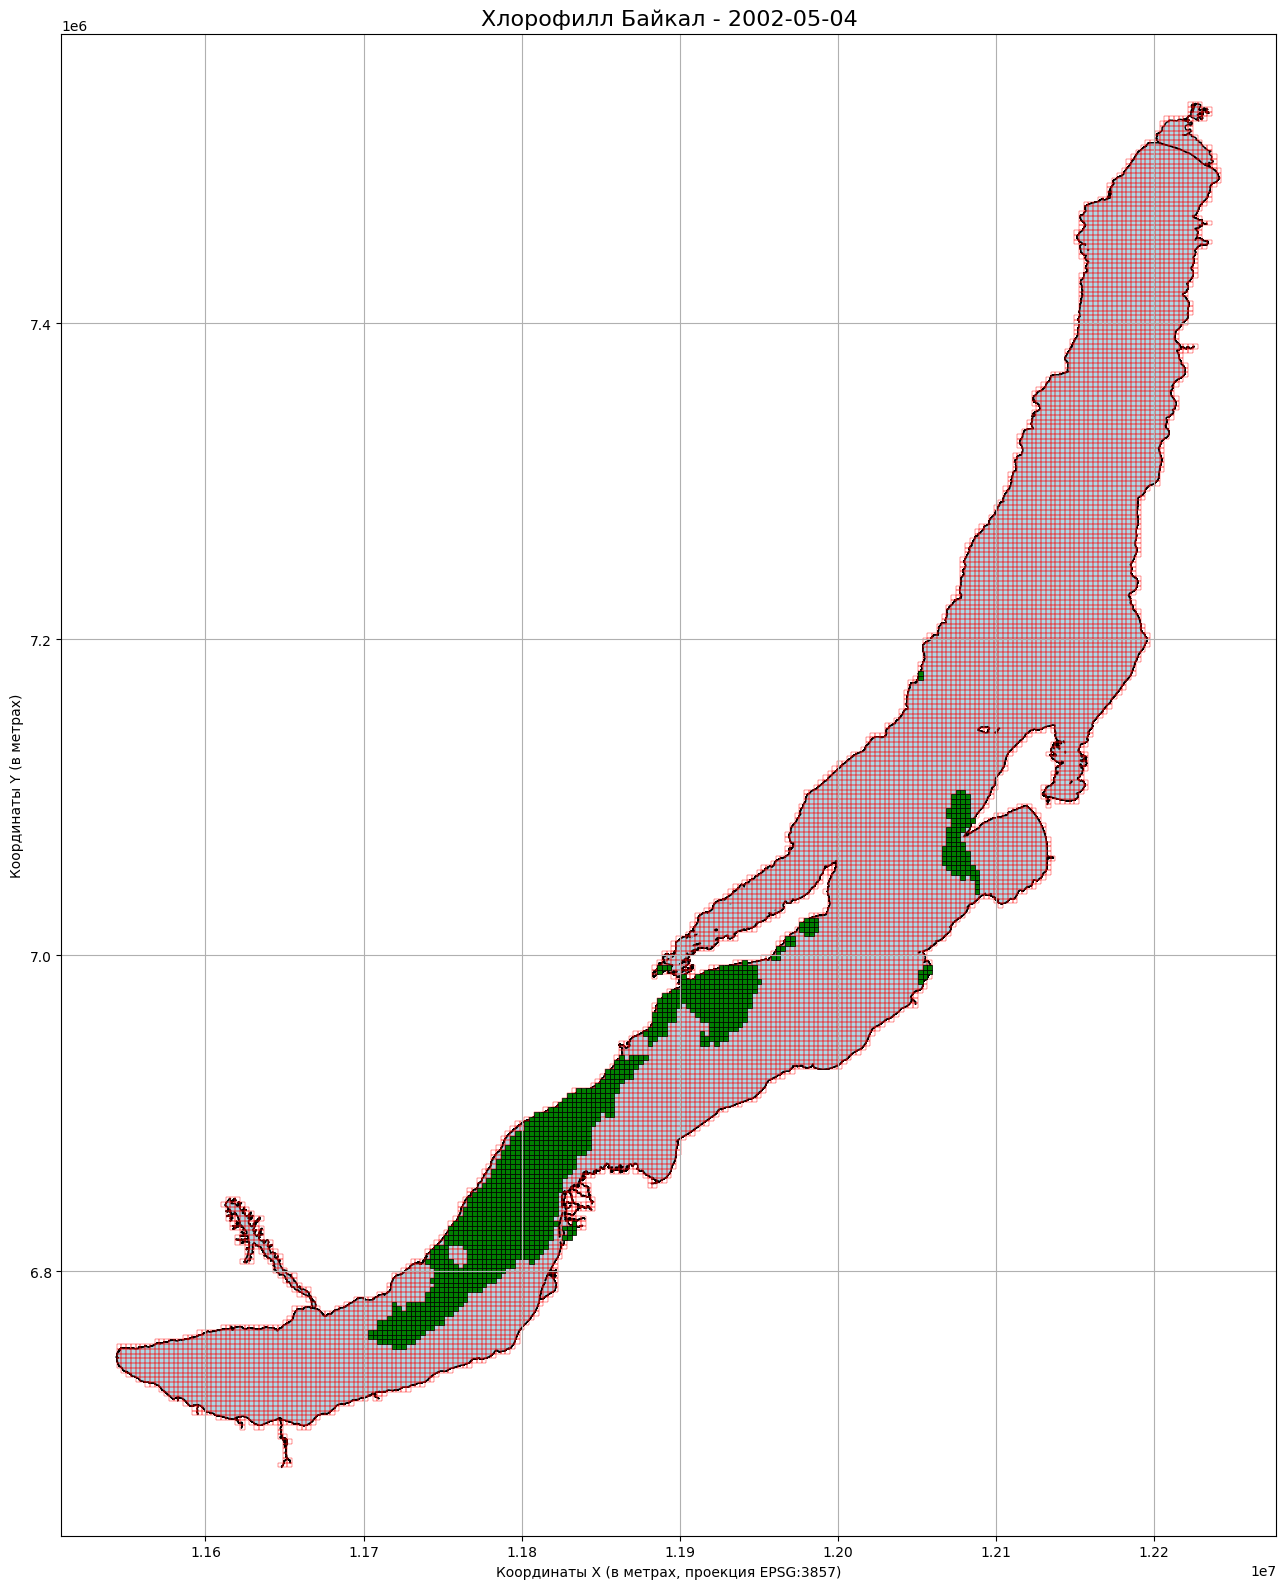

Изображение для 2002-05-04 сохранено и отображено.


C:\Users\fusb1\AppData\Local\Temp\ipykernel_11800\903519435.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6152297' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  grid_day.loc[cell_idx, "chla_mean"] = row['chla_mean']  # Записываем значение хлорофилла


Число клеток с хлорофиллом для 2002-05-18: 34


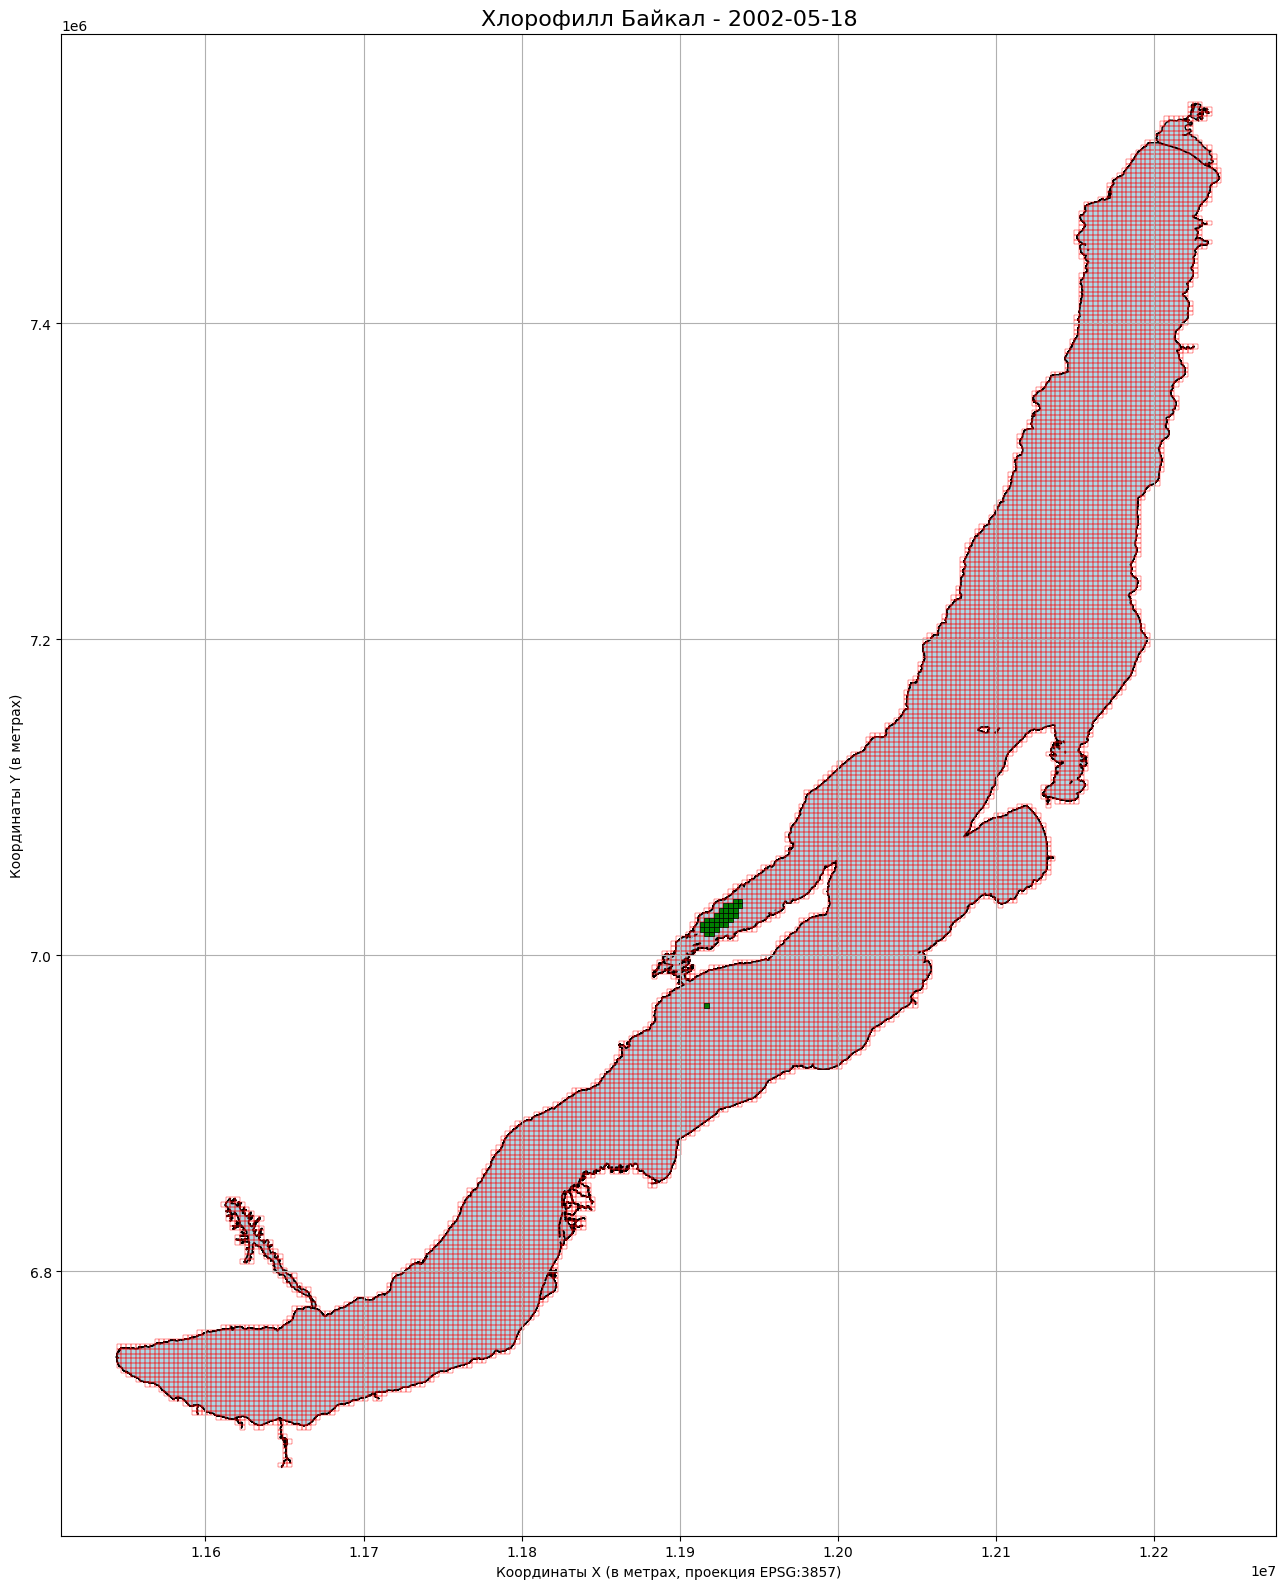

Изображение для 2002-05-18 сохранено и отображено.


C:\Users\fusb1\AppData\Local\Temp\ipykernel_11800\903519435.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.84288716' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  grid_day.loc[cell_idx, "chla_mean"] = row['chla_mean']  # Записываем значение хлорофилла


Число клеток с хлорофиллом для 2002-05-20: 723


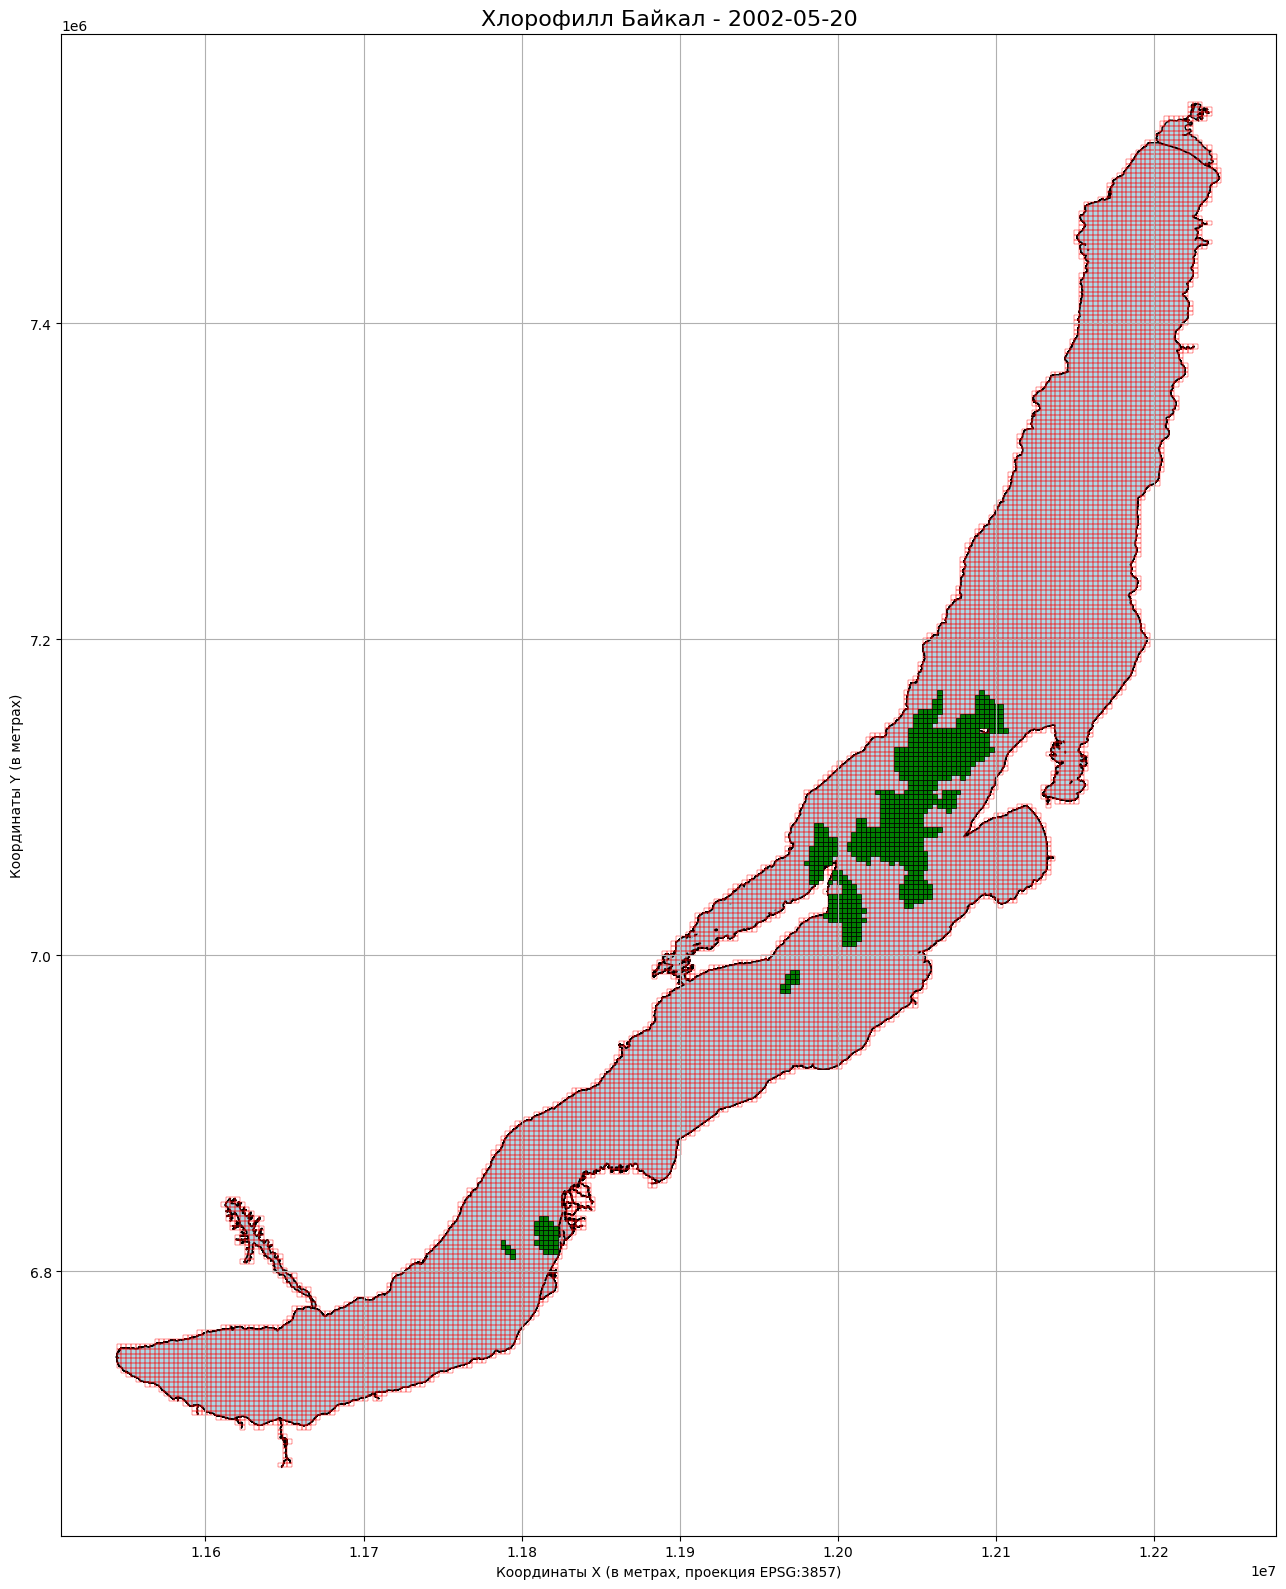

Изображение для 2002-05-20 сохранено и отображено.


C:\Users\fusb1\AppData\Local\Temp\ipykernel_11800\903519435.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.2623115' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  grid_day.loc[cell_idx, "chla_mean"] = row['chla_mean']  # Записываем значение хлорофилла


Число клеток с хлорофиллом для 2002-05-23: 7075


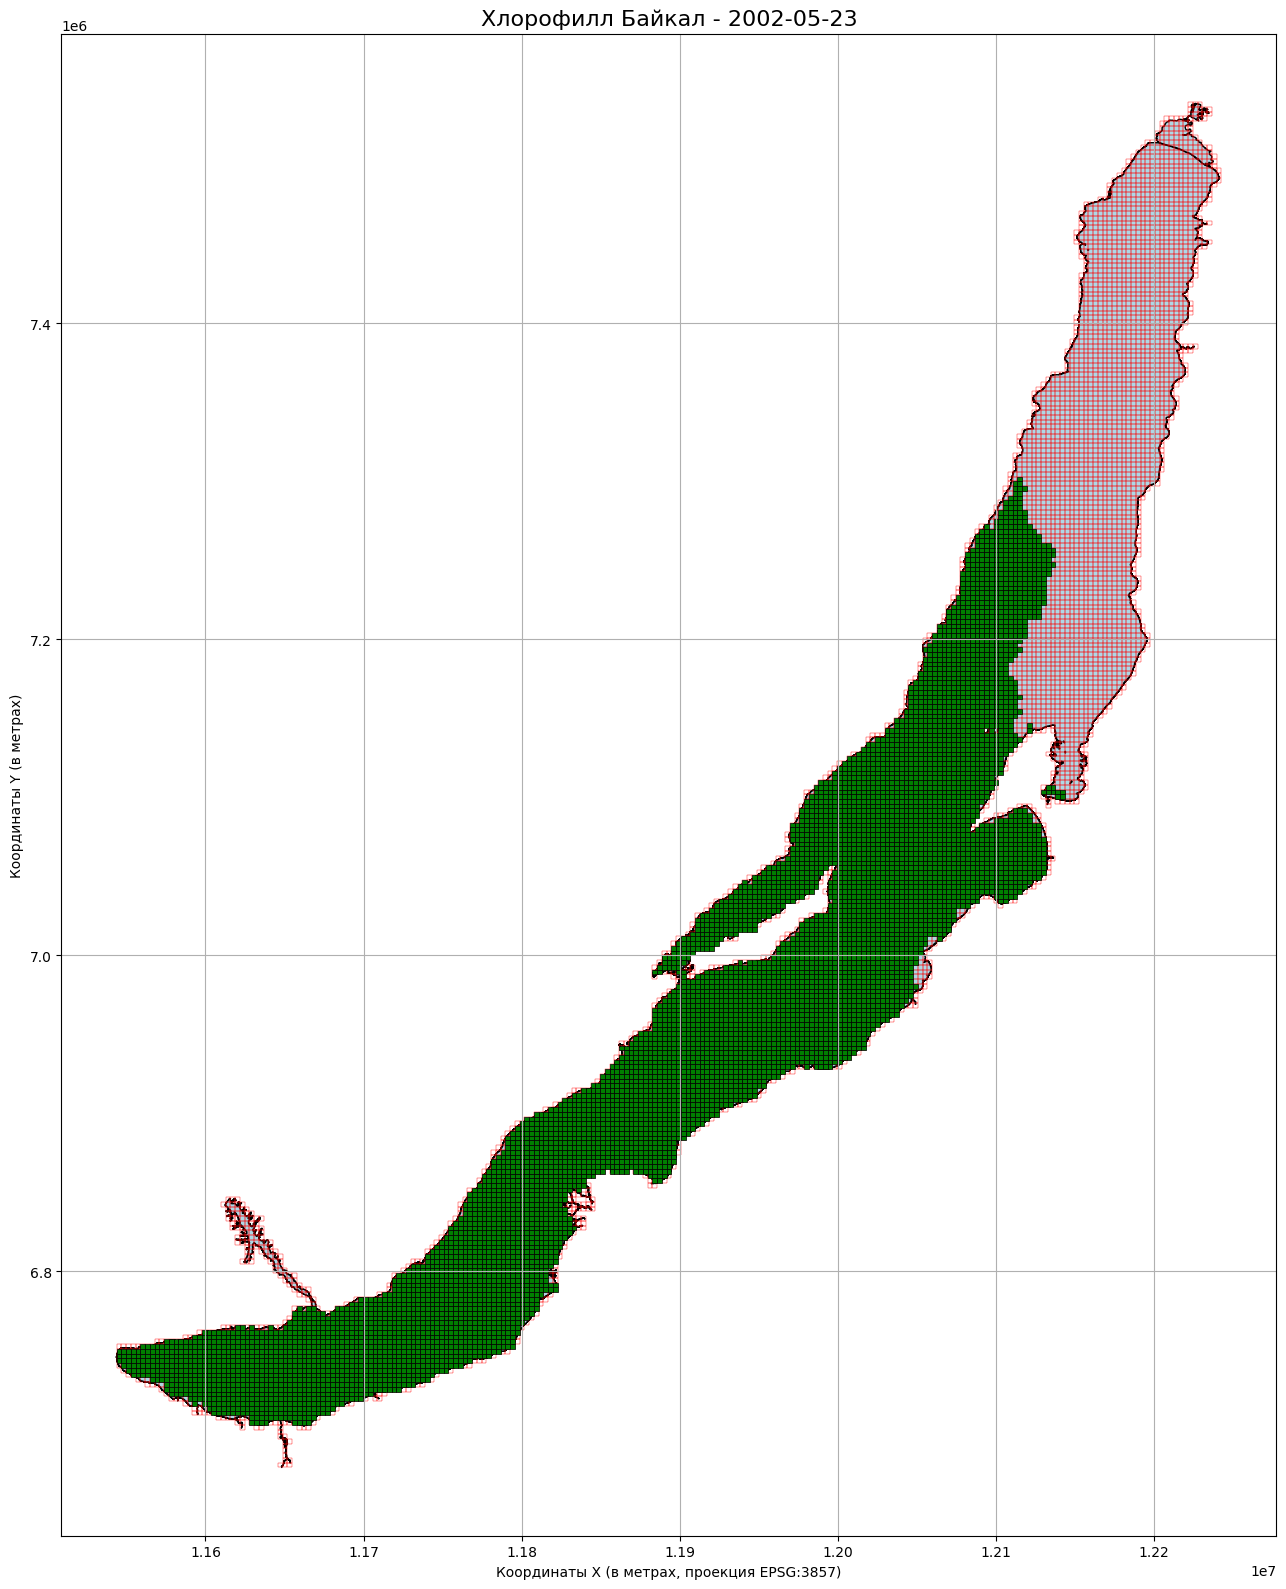

Изображение для 2002-05-23 сохранено и отображено.


In [ ]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point, box
import os

# Чтение данных из CSV
input_file = 'C:/Users/fusb1/Desktop/Для диплома/Хлорофилл в Байкале по годам_обработанный/Весь_Байкал_только_Хлорофилл_2002.csv'
df = pd.read_csv(input_file)

# Преобразуем координаты в проекцию EPSG:3857 (метры)
# Для этого создаем GeoDataFrame из таблицы с использованием проекции EPSG:4326 (градусы)
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_xy(df['lon'], df['lat'], crs="EPSG:4326"))
gdf = gdf.to_crs(epsg=3857)  # Переводим в метры

# Получаем геометрию озера Байкал
lake = ox.features_from_place("Lake Baikal, Russia", tags={"natural": "water"})
lake = lake[lake.geometry.type.isin(["Polygon", "MultiPolygon"])]

# Переводим в метрическую проекцию
lake = lake.to_crs(epsg=3857)

# Границы
minx, miny, maxx, maxy = lake.total_bounds
cell_size = 3000  # 3 км

# Сетка
grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        cell = box(x, y, x + cell_size, y + cell_size)
        grid_cells.append(cell)
        y += cell_size
    x += cell_size

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=lake.crs)

# Оставляем только клетки, пересекающиеся с озером
grid = grid[grid.intersects(lake.unary_union)].copy()

# Для начала фильтруем данные только для первого месяца
df['date'] = pd.to_datetime(df['date'])
first_month = df['date'].dt.month.min()
df_month = df[df['date'].dt.month == first_month]

# Создаем папку для сохранения изображений
output_folder = 'C:/Users/fusb1/Desktop/Для диплома/Хлорофилл в Байкале по годам_обработанный/Images_2002'
os.makedirs(output_folder, exist_ok=True)

# Проходим по уникальным датам первого месяца и генерируем изображения для каждого дня
for date in df_month['date'].unique():
    # Фильтруем данные по текущей дате
    df_day = df_month[df_month['date'] == date]

    # Преобразуем координаты в метры для этого дня
    gdf_day = gpd.GeoDataFrame(df_day, geometry=gpd.GeoSeries.from_xy(df_day['lon'], df_day['lat'], crs="EPSG:4326"))
    gdf_day = gdf_day.to_crs(epsg=3857)  # Переводим в метры

    # Функция для нахождения клетки для каждой точки
    def find_cell(lat, lon):
        point = Point(lon, lat)  # создаём точку из координат
        for idx, cell in grid.iterrows():
            if cell.geometry.contains(point):  # если точка внутри клетки
                return idx
        return None

    # Копируем сетку
    grid_day = grid.copy()
    grid_day["chla_mean"] = 0  # Инициализируем столбец для хлорофилла

    # Для каждой строки данных находим соответствующую клетку
    for _, row in gdf_day.iterrows():
        cell_idx = find_cell(row.geometry.y, row.geometry.x)  # Используем y (lat) и x (lon)
        if cell_idx is not None:
            grid_day.loc[cell_idx, "chla_mean"] = row['chla_mean']  # Записываем значение хлорофилла

    # Проверим, что значения хлорофилла записались корректно
    print(f"Число клеток с хлорофиллом для {date.strftime('%Y-%m-%d')}: {grid_day['chla_mean'].gt(0).sum()}")

    # Визуализация
    fig, ax = plt.subplots(figsize=(16, 16))
    lake.plot(ax=ax, color='lightblue', edgecolor='black')

    # Рисуем сетку (все клетки)
    grid.plot(ax=ax, color='none', edgecolor='red', linewidth=0.3)

    # Закрашиваем клетки с хлорофиллом (зелёным)
    grid_day[grid_day['chla_mean'] > 0].plot(ax=ax, color="green", edgecolor='black', linewidth=0.5)

    # Отображаем оси и сетку
    plt.title(f"Хлорофилл Байкал - {date.strftime('%Y-%m-%d')}", fontsize=16)
    plt.xlabel("Координаты X (в метрах, проекция EPSG:3857)")
    plt.ylabel("Координаты Y (в метрах)")
    plt.grid(True)

    # Сохраняем картинку в папку
    output_path = os.path.join(output_folder, f"Baikal_{date.strftime('%Y-%m-%d')}.png")
    plt.tight_layout()
    plt.savefig(output_path)
    
    # Также отображаем картинку на экране
    plt.show()

    plt.close()

    print(f"Изображение для {date.strftime('%Y-%m-%d')} сохранено и отображено.")
 